In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import *
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# Configuración para gráficos
%matplotlib inline

In [2]:
# 1. Cargar datos
X, y = load_breast_cancer(return_X_y=True)

# 2. Train-test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [3]:
# 3. Modelos
log = LogisticRegression(max_iter=500)
tree = DecisionTreeClassifier()

log.fit(X_train, y_train)
tree.fit(X_train, y_train)

c:\Users\tteru\.pyenv\pyenv-win\versions\3.12.8\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [4]:
# 4. Predicciones
pred_log = log.predict(X_test)
pred_tree = tree.predict(X_test)

In [5]:
# --- PASO 5: EVALUACIÓN ---

# Calculamos probabilidades para la curva ROC (necesario para AUC)
prob_log = log.predict_proba(X_test)[:, 1]
prob_tree = tree.predict_proba(X_test)[:, 1]

def imprimir_metricas(nombre, y_true, y_pred, y_prob):
    print(f"Resultados para: {nombre}")
    print(f"Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_true, y_pred):.4f}")
    print(f"F1 Score:  {f1_score(y_true, y_pred):.4f}")
    print(f"AUC:       {roc_auc_score(y_true, y_prob):.4f}")
    print("-" * 30)

imprimir_metricas("Regresión Logística", y_test, pred_log, prob_log)
imprimir_metricas("Árbol de Decisión", y_test, pred_tree, prob_tree)

Resultados para: Regresión Logística
Accuracy:  0.9561
Precision: 0.9844
Recall:    0.9403
F1 Score:  0.9618
AUC:       0.9933
------------------------------
Resultados para: Árbol de Decisión
Accuracy:  0.9035
Precision: 0.9516
Recall:    0.8806
F1 Score:  0.9147
AUC:       0.9084
------------------------------


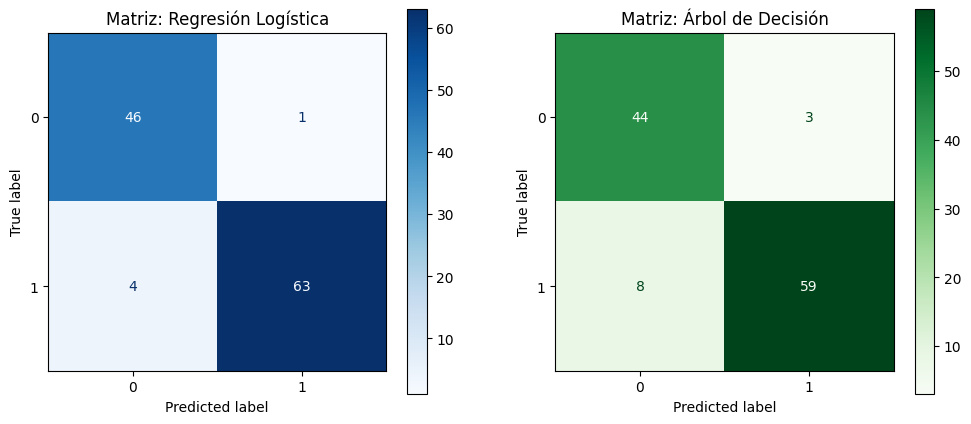

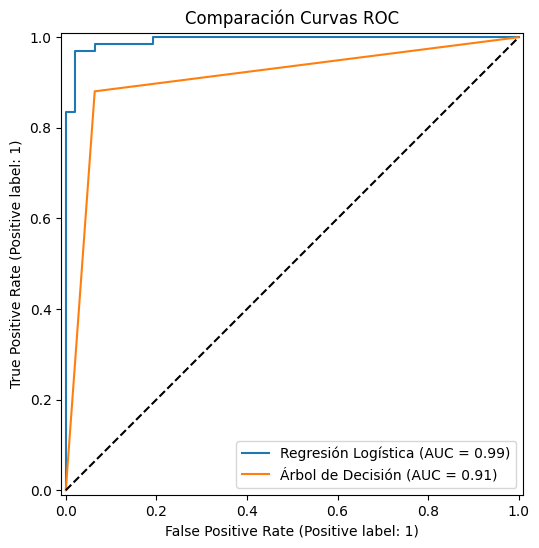

In [10]:
# Configurar figura para las matrices de confusión
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Matriz Logística
ConfusionMatrixDisplay.from_predictions(y_test, pred_log, ax=ax[0], cmap='Blues')
ax[0].set_title("Matriz: Regresión Logística")

# Matriz Árbol
ConfusionMatrixDisplay.from_predictions(y_test, pred_tree, ax=ax[1], cmap='Greens')
ax[1].set_title("Matriz: Árbol de Decisión")
plt.show()

# Gráfico de Curva ROC
plt.figure(figsize=(8, 6))
RocCurveDisplay.from_estimator(log, X_test, y_test, name="Regresión Logística", ax=plt.gca())
RocCurveDisplay.from_estimator(tree, X_test, y_test, name="Árbol de Decisión", ax=plt.gca())
plt.plot([0, 1], [0, 1], 'k--', label='Azar (0.5)')
plt.title("Comparación Curvas ROC")
plt.show()